# **Import packages and modules**

In [1]:
import numpy as np

In [2]:
from data.load_ratings import structure_data
from data.split import data_split
from visualization.loss_rmse_plots import loss_rmse
from visualization.power_law import compute_degrees, get_distribution, plot_power_law
from visualization.distributions import flatten_ratings, plot_rating_distribution, plot_ratings_by_user_movie
from models.als_core import   train_als



# **Pratical 1**

# MovieLens 32M Analysis Tasks

- [x] **Download the MovieLens 32M dataset**  
  Understand the dataset structure by reading its README file.  

- [x] **Create data structures to index the data**  
  - (a) Index by **user**: for each user, store all movies they rated and the ratings.  
  - (b) Index by **movie**: for each movie, store all users who rated it and the ratings.  

- [x] **Plot rating distributions**  
  Visualize the distribution of ratings across users and movies using histograms or density plots.  

- [x] **Analyze power-law behavior**  
  - Investigate whether the number of ratings per user and per movie follows a power law.  
  - Check if the network is **scale-free**.  
  - Note: Each user rated at least 20 movies, so the truncation may skew the expected power-law behavior.  


In [3]:
idx_to_movie, idx_to_user, movieid_to_idx, userid_to_idx, data_by_movie, data_by_user = structure_data()

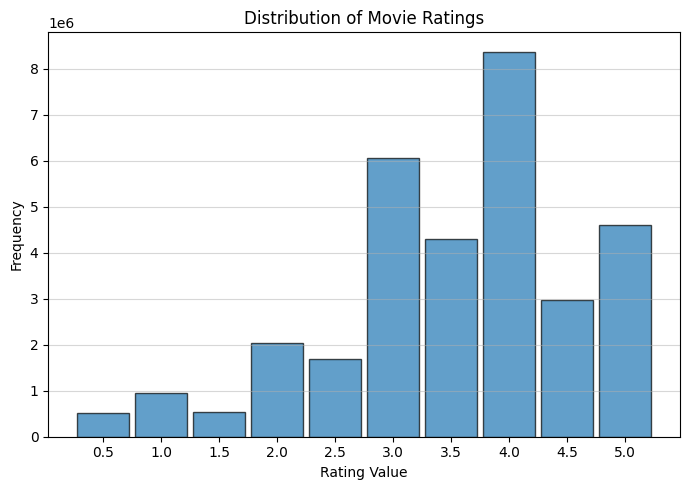

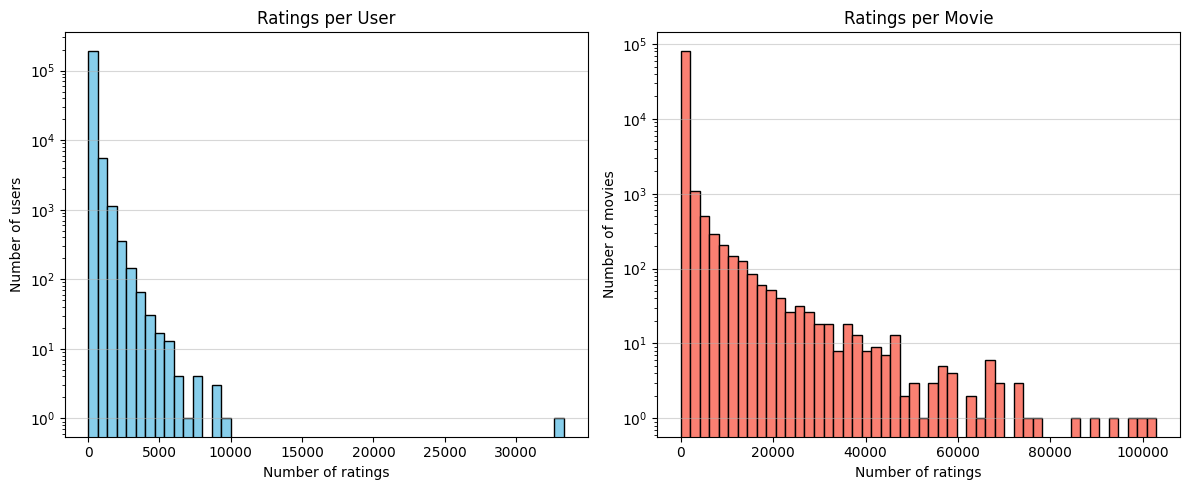

In [4]:
# Histogramm
ratings = flatten_ratings(data_by_user)
plot_rating_distribution(
    ratings, 
    bins=np.arange(0.25, 5.5, 0.5),
    save_path="pdf_reports/rating_distribution.pdf",
    title="Distribution of Movie Ratings"
)

# Histogrammes 
plot_ratings_by_user_movie(
    data_by_user, 
    data_by_movie, 
    save_path="pdf_reports/rating_by_user_movie.pdf"
)


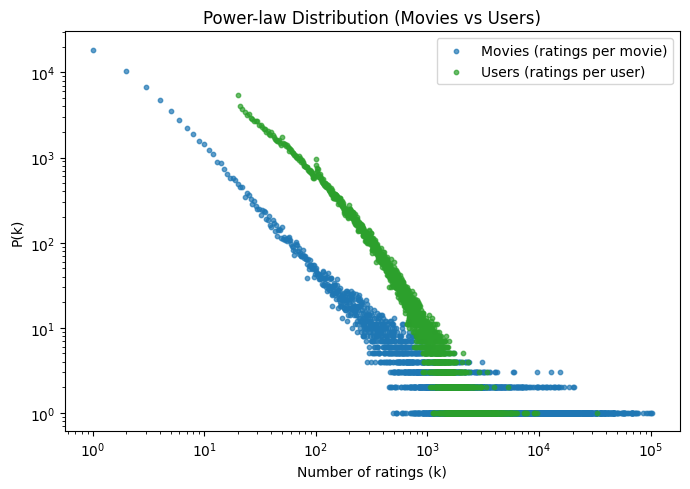

In [5]:
movie_degrees = compute_degrees(data_by_movie)
user_degrees  = compute_degrees(data_by_user)
movie_k, movie_p = get_distribution(movie_degrees)
user_k, user_p   = get_distribution(user_degrees)
plot_power_law(movie_k, movie_p, user_k, user_p, save_path="pdf_reports/power_law.pdf")


# **Slip data**

In [4]:
data_by_user_train, data_by_user_test, data_by_movie_train, data_by_movie_test  = data_split(data_by_movie, data_by_user) 

Train users: 200948, Movies: 84432
Test users:  200948, Movies: 84432


# Practical 2

## *Biases only model*  
  


In [13]:
from models.bias_only import   train_bias_only

Iter  1: Loss=3200126.212359, Train RMSE=0.861656, Test RMSE=0.871573
Iter  2: Loss=3091523.144565, Train RMSE=0.846904, Test RMSE=0.856819
Iter  3: Loss=3086174.327170, Train RMSE=0.846172, Test RMSE=0.856116
Iter  4: Loss=3085814.845644, Train RMSE=0.846123, Test RMSE=0.856075
Iter  5: Loss=3085776.497982, Train RMSE=0.846117, Test RMSE=0.856072
Iter  6: Loss=3085769.879636, Train RMSE=0.846116, Test RMSE=0.856071
Iter  7: Loss=3085768.276775, Train RMSE=0.846116, Test RMSE=0.856071
Iter  8: Loss=3085767.705543, Train RMSE=0.846116, Test RMSE=0.856071
Iter  9: Loss=3085767.365461, Train RMSE=0.846116, Test RMSE=0.856071
Iter 10: Loss=3085767.077955, Train RMSE=0.846116, Test RMSE=0.856070
Iter 11: Loss=3085766.804668, Train RMSE=0.846116, Test RMSE=0.856070
Iter 12: Loss=3085766.534318, Train RMSE=0.846116, Test RMSE=0.856070
Iter 13: Loss=3085766.264357, Train RMSE=0.846116, Test RMSE=0.856070
Iter 14: Loss=3085765.994690, Train RMSE=0.846116, Test RMSE=0.856070
Iter 15: Loss=308576

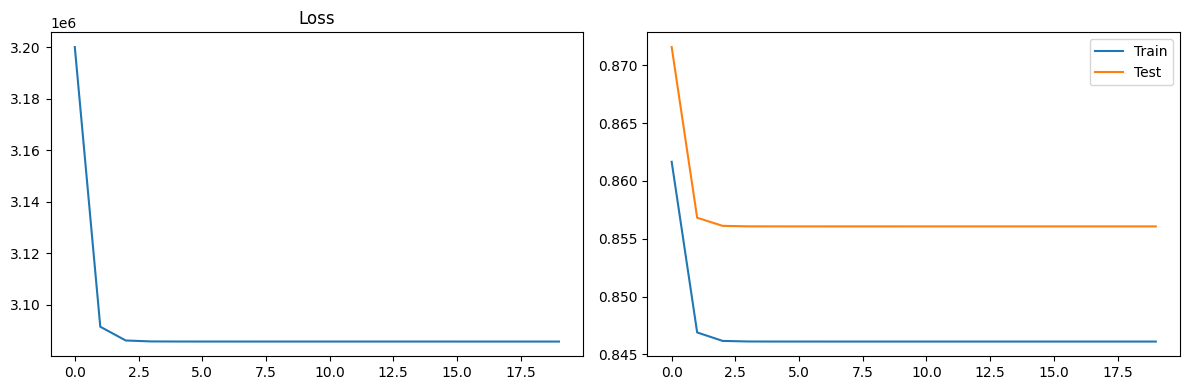

In [17]:
user_biases, item_biases, loss_hist, train_rmse_hist, test_rmse_hist = train_bias_only(
    data_by_user_train, data_by_movie_train, data_by_user_test,
    lambda_val=0.3, gamma=0.002, n_iters=20)
loss_rmse(loss_hist, train_rmse_hist, test_rmse_hist,filename ="pdf_reports/rmse_and_loss_bias_model.pdf")

# **Practical 3**

## **ALS model with emeddings**

Iter 1: Train RMSE=0.8363, Test RMSE=0.8711, Loss=1078084.6868
Iter 2: Train RMSE=0.7485, Test RMSE=0.8162, Loss=911222.4704
Iter 3: Train RMSE=0.7225, Test RMSE=0.7925, Loss=864908.8981
Iter 4: Train RMSE=0.7124, Test RMSE=0.7829, Loss=847465.9533
Iter 5: Train RMSE=0.7075, Test RMSE=0.7784, Loss=839135.7396
Iter 6: Train RMSE=0.7048, Test RMSE=0.7758, Loss=834316.0970
Iter 7: Train RMSE=0.7031, Test RMSE=0.7742, Loss=831149.6277
Iter 8: Train RMSE=0.7019, Test RMSE=0.7731, Loss=828920.4012
Iter 9: Train RMSE=0.7010, Test RMSE=0.7723, Loss=827286.5491
Iter 10: Train RMSE=0.7004, Test RMSE=0.7718, Loss=826045.6074
Iter 11: Train RMSE=0.7000, Test RMSE=0.7713, Loss=825067.5806
Iter 12: Train RMSE=0.6996, Test RMSE=0.7710, Loss=824268.8208
Iter 13: Train RMSE=0.6993, Test RMSE=0.7708, Loss=823595.4410
Iter 14: Train RMSE=0.6991, Test RMSE=0.7706, Loss=823012.0842
Iter 15: Train RMSE=0.6989, Test RMSE=0.7705, Loss=822494.9026
Iter 16: Train RMSE=0.6988, Test RMSE=0.7703, Loss=822027.3797


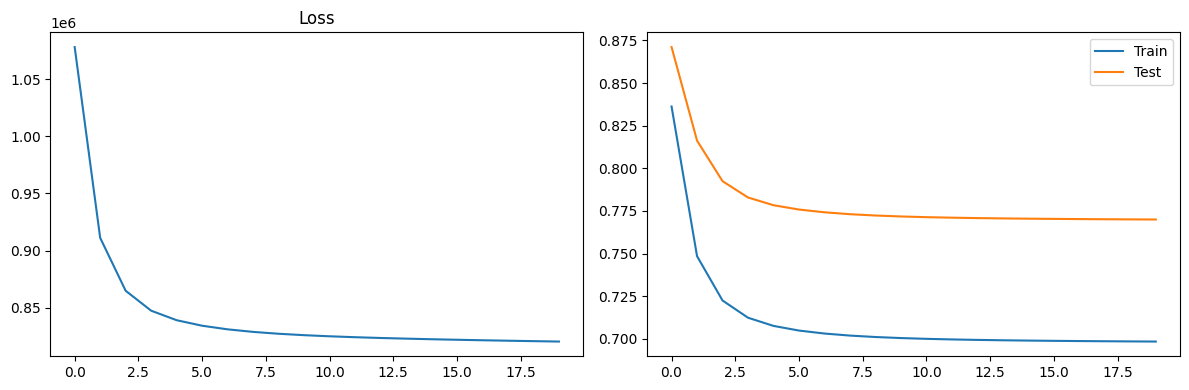

In [5]:
user_factors, item_factors , user_biases, item_biases, loss_hist, train_rmse, test_rmse = train_als(
    data_by_user_train, data_by_movie_train, data_by_user_test,
    factor_number= 15, lambda_val= 0.1, gamma=0.04, tau= 1.9, n_iters=20
)
loss_rmse(loss_hist, train_rmse, test_rmse, filename ="pdf_reports/rmse_and_loss_full_model.pdf")

### **Comparaison of split data  standard versus Split by user**

Train users:        180853
Test users:         20095
Train interactions:28790296
Test interactions: 3209908
Iter 1: Train RMSE=0.8358, Test RMSE=3.6581, Loss=1077013.6899
Iter 2: Train RMSE=0.7487, Test RMSE=3.6740, Loss=909769.8146
Iter 3: Train RMSE=0.7238, Test RMSE=3.6821, Loss=865163.1264
Iter 4: Train RMSE=0.7142, Test RMSE=3.6848, Loss=848632.0498
Iter 5: Train RMSE=0.7095, Test RMSE=3.6845, Loss=840499.1589
Iter 6: Train RMSE=0.7068, Test RMSE=3.6825, Loss=835779.4181
Iter 7: Train RMSE=0.7051, Test RMSE=3.6794, Loss=832741.8673
Iter 8: Train RMSE=0.7040, Test RMSE=3.6755, Loss=830665.0489
Iter 9: Train RMSE=0.7032, Test RMSE=3.6710, Loss=829188.6916
Iter 10: Train RMSE=0.7027, Test RMSE=3.6661, Loss=828098.8888
Iter 11: Train RMSE=0.7023, Test RMSE=3.6610, Loss=827259.8734
Iter 12: Train RMSE=0.7020, Test RMSE=3.6556, Loss=826585.6463
Iter 13: Train RMSE=0.7017, Test RMSE=3.6500, Loss=826022.3330
Iter 14: Train RMSE=0.7015, Test RMSE=3.6443, Loss=825536.1497
Iter 15: Train RMS

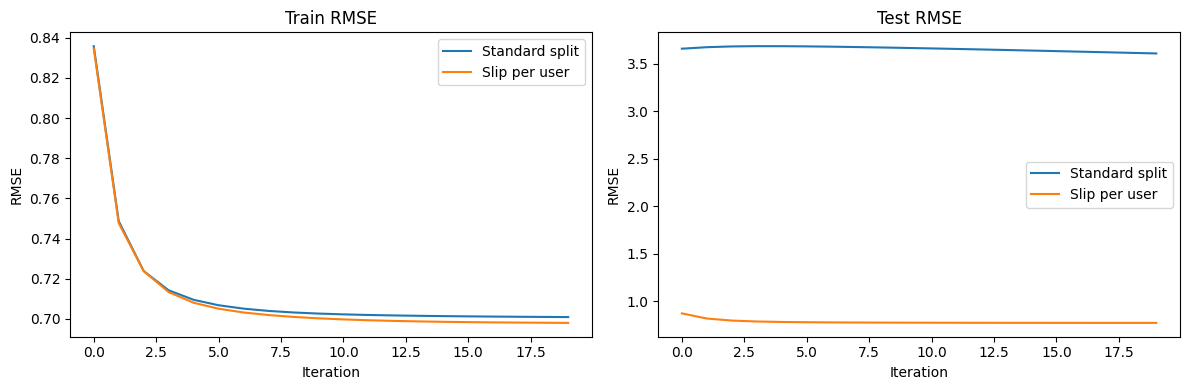

In [6]:
from data.split import data_split, data_split_standard
from visualization.split_comparaison_plot import plot_split_comparaison

splits = {
    "standard": {
        "label": "Standard split",
        "marker": "s",
        "split_fn": lambda: data_split_standard(
            data_by_movie, data_by_user, threshold=0.9
        )
    },
    "custom": {
        "label": "Slip per user",
        "marker": "o",
        "split_fn": lambda: data_split(
            data_by_movie, data_by_user
        )
    },
}

data = {}

for key, cfg in splits.items():
    u_tr, u_te, m_tr, m_te = cfg["split_fn"]()

    _, _, _, _, _, train_rmse, test_rmse = train_als(
        u_tr, m_tr, u_te,
        factor_number=15,
        lambda_val=0.1,
        gamma=0.04,
        tau=1.9,
        n_iters=20
    )

    data[key] = {
        "train_rmse": train_rmse,
        "test_rmse": test_rmse
    }

plot_split_comparaison(data, splits)


# **Practical 4**

### **Optimisation and tuning**


 **Training and Evaluation**  
- Optimize parameters **only on the training set**.  
- Measure **RMSE** on both training and test sets.  
- Plot **train vs test RMSE** on the same graph over training iterations.  
- Identify where **overfitting occurs**.  
- Compare overfitting for **K=20 vs K=10 latent dimensions**.  
- Check **which users** are affected.  
- Investigate **underfitting**.  
- Explore how **λ (regularization) and τ** influence results.

 **Final Training**  
- Once satisfied with K, λ, and τ, **train the model on the full dataset**.

/home/aimeloick/Documents/ML-SCALE/recommender_als/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-01-10 11:33:54,926] A new study created in memory with name: no-name-928e1f16-1ebf-44b4-8337-da83582f5467
Optimisation Optuna:   0%|          | 0/50 [00:00<?, ?it/s][I 2026-01-10 11:33:54,940] Trial 0 finished with value: inf and parameters: {'tau': 0.20411089908720018, 'gamma': 0.056593085965800954, 'K': 11}. Best is trial 0 with value: inf.
[I 2026-01-10 11:33:54,942] Trial 1 finished with value: inf and parameters: {'tau': 0.17274342120991729, 'gamma': 0.0015979534370920128, 'K': 20}. Best is trial 0 with value: inf.
[I 2026-01-10 11:33:54,945] Trial 2 finished with value: inf and parameters: {'tau': 0.02563177176309112, 'gamma': 0.1813323820272875, 'K': 20}. Best is trial 0 with value: inf

Best tau: 0.20411089908720018
Best gamma: 0.056593085965800954
Best K: 11
Validation RMSE: inf


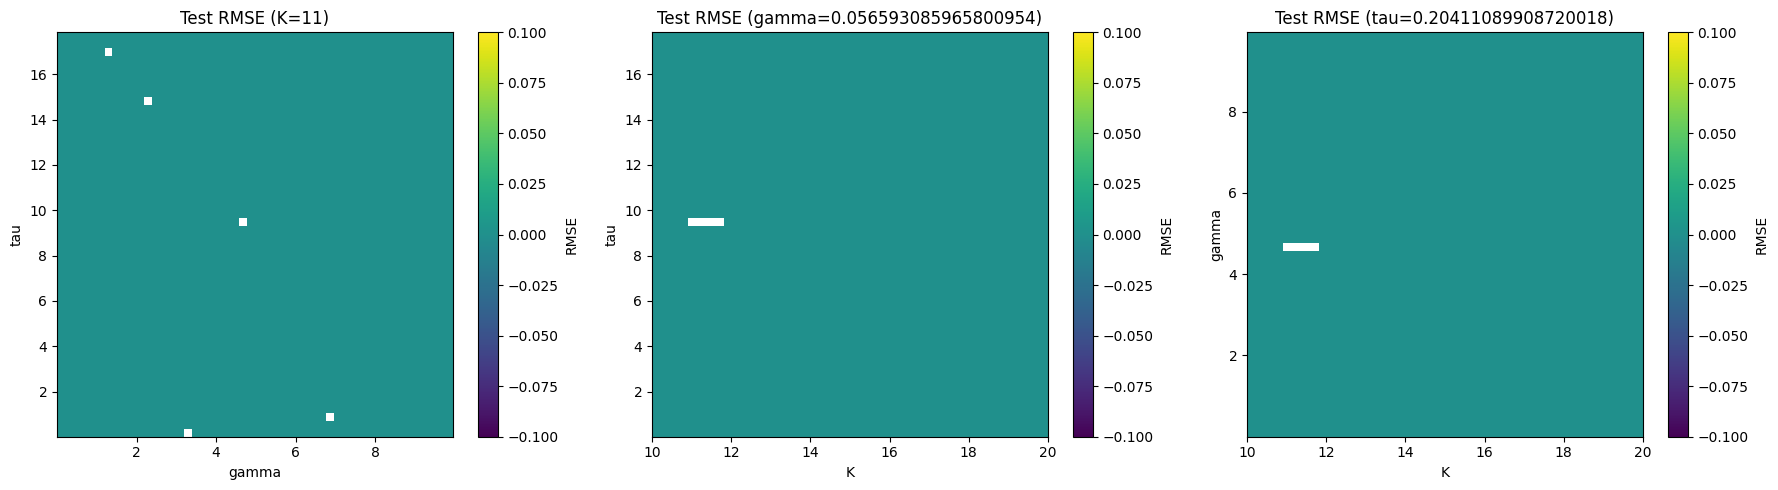

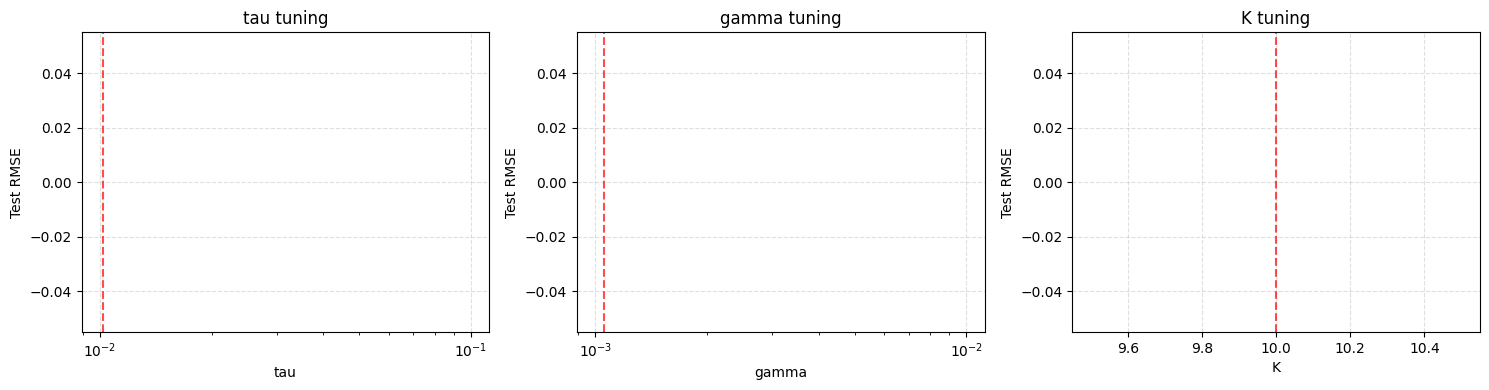


Training ALS with K = 0
Iter 1: Train RMSE=0.8609, Test RMSE=0.8707, Loss=756988.9113
Iter 2: Train RMSE=0.8475, Test RMSE=0.8572, Loss=732867.8332
Iter 3: Train RMSE=0.8471, Test RMSE=0.8568, Loss=730633.8666
Iter 4: Train RMSE=0.8470, Test RMSE=0.8568, Loss=729424.8134
Iter 5: Train RMSE=0.8470, Test RMSE=0.8567, Loss=728295.3628
Iter 6: Train RMSE=0.8470, Test RMSE=0.8567, Loss=727191.3212
Iter 7: Train RMSE=0.8470, Test RMSE=0.8567, Loss=726107.8973
Iter 8: Train RMSE=0.8470, Test RMSE=0.8567, Loss=725044.1280
Iter 9: Train RMSE=0.8470, Test RMSE=0.8567, Loss=723999.5460
Iter 10: Train RMSE=0.8469, Test RMSE=0.8566, Loss=722973.7813
Iter 11: Train RMSE=0.8469, Test RMSE=0.8566, Loss=721966.4894
Iter 12: Train RMSE=0.8469, Test RMSE=0.8566, Loss=720977.3364
Iter 13: Train RMSE=0.8469, Test RMSE=0.8566, Loss=720005.9955
Iter 14: Train RMSE=0.8469, Test RMSE=0.8566, Loss=719052.1457
Iter 15: Train RMSE=0.8469, Test RMSE=0.8566, Loss=718115.4722
Iter 16: Train RMSE=0.8469, Test RMSE=0

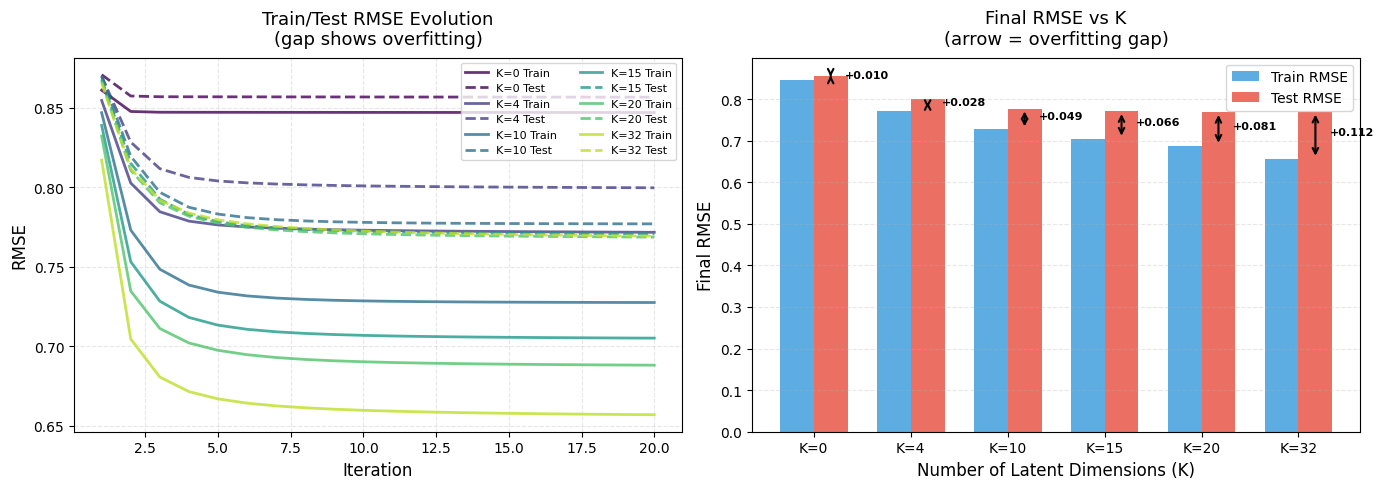


OVERFITTING ANALYSIS
K= 0 → Train: 0.8469 | Test: 0.8565 | Gap: 0.0097 (1.1%)
K= 4 → Train: 0.7716 | Test: 0.7995 | Gap: 0.0280 (3.6%)
K=10 → Train: 0.7274 | Test: 0.7769 | Gap: 0.0494 (6.8%)
K=15 → Train: 0.7050 | Test: 0.7706 | Gap: 0.0655 (9.3%)
K=20 → Train: 0.6880 | Test: 0.7685 | Gap: 0.0805 (11.7%)
K=32 → Train: 0.6569 | Test: 0.7692 | Gap: 0.1123 (17.1%)

DIMINISHING RETURNS ANALYSIS
0→4: Δ=0.0570 (6.65%) ✅ Worth it
4→10: Δ=0.0227 (2.84%) ✅ Worth it
10→15: Δ=0.0063 (0.81%) ✅ Worth it
15→20: Δ=0.0020 (0.26%) ⚠️ Diminishing
20→32: Δ=-0.0006 (-0.08%) ⚠️ Diminishing

🎯 Best K: 20 (Test RMSE: 0.7685)


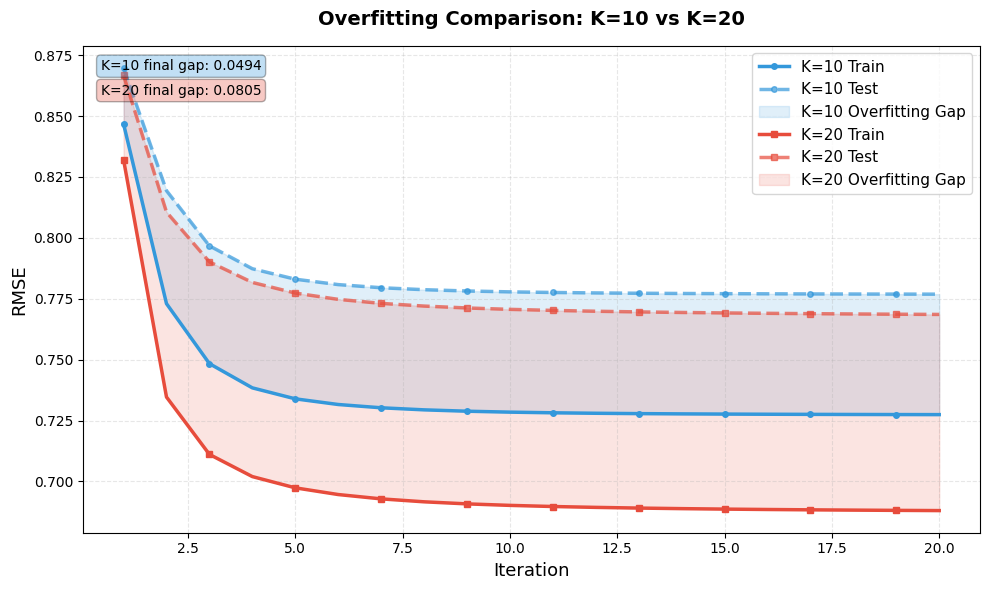

Training K=20 ...
Iter 1: Train RMSE=0.8289, Test RMSE=0.8717, Loss=1065977.6352
Iter 2: Train RMSE=0.7333, Test RMSE=0.8174, Loss=889788.8892
Iter 3: Train RMSE=0.7076, Test RMSE=0.7947, Loss=844608.1346
Iter 4: Train RMSE=0.6967, Test RMSE=0.7844, Loss=825790.0467
Iter 5: Train RMSE=0.6911, Test RMSE=0.7791, Loss=816213.1959
Iter 6: Train RMSE=0.6878, Test RMSE=0.7759, Loss=810635.5591
Iter 7: Train RMSE=0.6858, Test RMSE=0.7740, Loss=807068.7700
Iter 8: Train RMSE=0.6844, Test RMSE=0.7727, Loss=804615.5908
Iter 9: Train RMSE=0.6834, Test RMSE=0.7718, Loss=802821.2926
Iter 10: Train RMSE=0.6827, Test RMSE=0.7710, Loss=801439.9716
Iter 11: Train RMSE=0.6821, Test RMSE=0.7705, Loss=800331.6179
Iter 12: Train RMSE=0.6817, Test RMSE=0.7700, Loss=799412.4638
Iter 13: Train RMSE=0.6813, Test RMSE=0.7697, Loss=798630.0293
Iter 14: Train RMSE=0.6810, Test RMSE=0.7694, Loss=797950.0045
Iter 15: Train RMSE=0.6808, Test RMSE=0.7691, Loss=797349.0653
Iter 16: Train RMSE=0.6806, Test RMSE=0.7689,

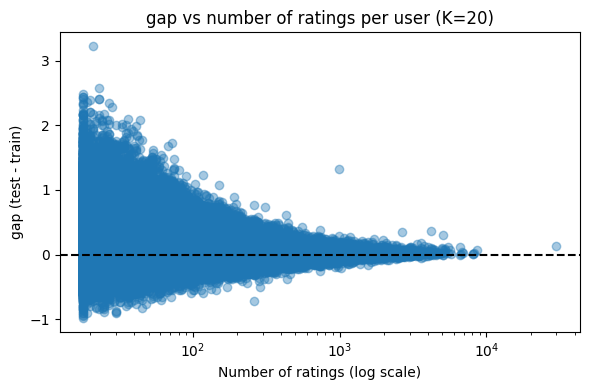

In [ ]:
import optuna
from tqdm import tqdm
from visualization.heatmaps import heatmaps_3params_from_study, plot_all_params
from visualization.overfitting_checking import plot_gap_vs_counts 
from tuning.overfitting_checking import evaluate_over_K, evaluate_over_K_with_f
from tuning.hierarchical import run_als_experiment_ks

results_list = []

def objective(trial):
    tau   = trial.suggest_float("tau", 1e-2, 2e1, log=True)
    gamma = trial.suggest_float("gamma", 1e-3, 1e1, log=True)
    K     = trial.suggest_int("K", 10, 20)

    n_iters = 0
    patience = 2
    best_val_rmse = float("inf")
    best_iter = 0
    train_rmse_history = []
    val_rmse_history = []

    # Early stopping
    for it in range(n_iters):
        user_vectors, biases_vectors, user_biases, item_biases, loss_hist, train_rmse, val_rmse = train_als(
                                                                                                            data_by_user_train=data_by_user_train,
                                                                                                            data_by_item_train=data_by_movie_train,
                                                                                                            data_by_user_test=data_by_user_test,
                                                                                                            factor_number=int(K),  
                                                                                                            lambda_val=1,
                                                                                                            gamma=gamma,
                                                                                                            tau=tau,
                                                                                                            n_iters=15,
                                                                                                            verbose=False
                                                                                                        )

        train_rmse_history.append(train_rmse[-1])
        val_rmse_history.append(val_rmse[-1])

        if val_rmse[-1] < best_val_rmse:
            best_val_rmse = val_rmse[-1]
            best_iter = it
        elif it - best_iter >= patience:
            break

    results_list.append({
        "tau": tau,
        "gamma": gamma,
        "K": K,
        "train_rmse": train_rmse_history,
        "val_rmse": val_rmse_history,
        "best_val_rmse": best_val_rmse
    })

    return best_val_rmse

# Optuna m
study = optuna.create_study(direction="minimize")
n_trials = 50
for _ in tqdm(range(n_trials), desc="Optimisation Optuna"):
    study.optimize(objective, n_trials=1)

# Best parameters
print("Best tau:", study.best_params["tau"])
print("Best gamma:", study.best_params["gamma"])
print("Best K:", study.best_params["K"])
print("Validation RMSE:", study.best_value)



# Call plots
heatmaps_3params_from_study(results_list, study)
plot_all_params(results_list)



Ks = [0, 4, 10, 15, 20 , 32]

rmse_history = run_als_experiment_ks(data_by_user_train, data_by_user_test, \
    data_by_movie_train, data_by_movie_test,
    Ks=Ks,
    n_iters=20,
    plot_filename="k_evolution_checking"
)

results = evaluate_over_K(train_als, 20, data_by_user_train, data_by_movie_train, data_by_user_test,
                        lambda_val=0.1, gamma=0.04, tau=1.9, n_iters=20)

plot_gap_vs_counts(results, 20)




#### Heatmaps plots

In [ ]:
from visualization.plot_optimisation import heatmap_around_best

In [ ]:
# Simple usage:
# 1. Fix K=15, explore tau and gamma around your best values
heatmap_around_best(data_by_user_train, data_by_movie_train,
                    data_by_user_test, data_by_movie_test,
                    fixed_param='K', fixed_value=15,
                    tau_center=1.9, gamma_center=0.04,
                    n_points=5, range_factor=3)

# 2. Fix tau, explore K and gamma
heatmap_around_best(data_by_user_train, data_by_movie_train,
                    data_by_user_test, data_by_movie_test,
                    fixed_param='tau', fixed_value=1.9,
                    gamma_center=0.04,
                    n_points=5, range_factor=3)

# 3. Fix gamma, explore K and tau
heatmap_around_best(data_by_user_train, data_by_movie_train,
                    data_by_user_test, data_by_movie_test,
                    fixed_param='gamma', fixed_value=0.04,
                    tau_center=1.9,
                    n_points=5, range_factor=3)

In [10]:
from polarisation.top_polarisation import compute_polarization, select_movies_by_polarization, build_polarization_dataframe
from visualization.polarisation import plot_top_polarization, plot_polarization_vs_count, plot_polarization_with_std
from prediction.dummy_user import build_dummy_rating
from prediction.recommend import compute_dummy_user
from visualization.prediction import  plot_dummy_user_predictions

In [11]:

movie_title = "Lord of the Rings: The Two Towers, The (2002)"

dummy_ratings, dummy_movie_idx , _ , movieid_to_title = build_dummy_rating(
    movie_title,
    movieid_to_idx,
    rating_value=5.0,
    movies_csv_path="ml-32m/movies.csv"
)

print("Dummy ratings:", dummy_ratings)

dummy_user_factors, dummy_user_bias = compute_dummy_user(item_factors, item_biases, dummy_ratings, K = 15,
    lambda_val=0.1,
    tau=1.9,
    gamma_bias=0.04
)

print("Dummy user latent factors:", dummy_user_factors)
print("Dummy user bias:", dummy_user_bias)

Dummy ratings: [(596, 5.0)]
Dummy user latent factors: [-0.11967712  0.07765455 -0.08255099 -0.07289962 -0.0434089  -0.05578087
  0.09861231 -0.14562908  0.12887074 -0.01331256  0.11221538  0.18079734
  0.04507342  0.04800862  0.13552427]
Dummy user bias: 0.55795527


### **Prediction for model without features embeddings**

#### **To filtre movie with few ratings**

In [ ]:
# Minimum number of ratings required
MIN_RATINGS = 100

# Count ratings per item index
item_rating_counts = {
    movie_idx: len(ratings)
    for movie_idx, ratings in enumerate(data_by_movie_train)
}

#### **prediction now**

In [15]:
# -------- Predictions --------
num_items = item_factors.shape[0]

predictions_full_bias = []
predictions_scaled_bias = []

for item_idx in range(num_items):
     # --- Filter low-support movies ---
    score_full_bias = (
        np.dot(dummy_user_factors, item_factors[item_idx])
        + item_biases[item_idx]
    )

    score_scaled_bias = (
        np.dot(dummy_user_factors, item_factors[item_idx])
        + 0.05 * item_biases[item_idx]
    )

    predictions_full_bias.append((item_idx, score_full_bias))
    predictions_scaled_bias.append((item_idx, score_scaled_bias))

# -------- Tri --------
predictions_full_bias.sort(key=lambda x: x[1], reverse=True)
predictions_scaled_bias.sort(key=lambda x: x[1], reverse=True)

print("\n🎬 Top 10 Recommendations (bias complet)")
for item_idx, score in predictions_full_bias[:10]:

    movie_id = idx_to_movie[item_idx]
    title = movieid_to_title.get(movie_id, f"MovieIdx {item_idx}")

    print(f"- {title} | Score prédit : {score:.4f}")

print("\n🎬 Top 10 Recommendations (bias pondéré 0.05)")
for item_idx, score in predictions_scaled_bias[:10]:

    movie_id = idx_to_movie[item_idx]
    title = movieid_to_title.get(movie_id, f"MovieIdx {item_idx}")

    print(f"- {title} | Score prédit : {score:.4f}")


🎬 Top 10 Recommendations (bias complet)
- Lord of the Rings: The Return of the King, The (2003) | Score prédit : 4.2651
- Lord of the Rings: The Fellowship of the Ring, The (2001) | Score prédit : 4.2295
- Lord of the Rings: The Two Towers, The (2002) | Score prédit : 4.1863
- Wesley (2009) | Score prédit : 2.4338
- Destination: Pluto Beyond the Flyby (2016) | Score prédit : 2.3976
- SpongeBob SquarePants: Tide and Seek | Score prédit : 2.3433
- SpongeBob SquarePants: Heroes of Bikini Bottom (2011) | Score prédit : 2.3433
- WWE: The Triumph and Tragedy of World Class Championship Wrestling (2007) | Score prédit : 2.3433
- The Sound of Violet (2022) | Score prédit : 2.2596
- Braveheart (1995) | Score prédit : 2.1533

🎬 Top 10 Recommendations (bias pondéré 0.05)
- Lord of the Rings: The Return of the King, The (2003) | Score prédit : 3.7423
- Lord of the Rings: The Fellowship of the Ring, The (2001) | Score prédit : 3.6960
- Lord of the Rings: The Two Towers, The (2002) | Score prédit :

Iter 1: Train RMSE=0.8574, Test RMSE=0.8708, Loss=1113972.6898
Iter 2: Train RMSE=0.8181, Test RMSE=0.8368, Loss=1027741.1387
Iter 3: Train RMSE=0.8063, Test RMSE=0.8260, Loss=1004255.1534
Iter 4: Train RMSE=0.8018, Test RMSE=0.8219, Loss=995597.9329
Iter 5: Train RMSE=0.7995, Test RMSE=0.8198, Loss=991318.3358
Iter 6: Train RMSE=0.7983, Test RMSE=0.8186, Loss=988851.5553
Iter 7: Train RMSE=0.7975, Test RMSE=0.8178, Loss=987213.5786
Iter 8: Train RMSE=0.7970, Test RMSE=0.8173, Loss=986021.2364
Iter 9: Train RMSE=0.7966, Test RMSE=0.8170, Loss=985106.3310
Iter 10: Train RMSE=0.7964, Test RMSE=0.8167, Loss=984372.3809
Iter 11: Train RMSE=0.7962, Test RMSE=0.8165, Loss=983758.3860
Iter 12: Train RMSE=0.7960, Test RMSE=0.8164, Loss=983226.3137
Iter 13: Train RMSE=0.7959, Test RMSE=0.8163, Loss=982752.4133
Iter 14: Train RMSE=0.7958, Test RMSE=0.8162, Loss=982321.4437
Iter 15: Train RMSE=0.7957, Test RMSE=0.8161, Loss=981923.2369
Iter 16: Train RMSE=0.7956, Test RMSE=0.8160, Loss=981550.705

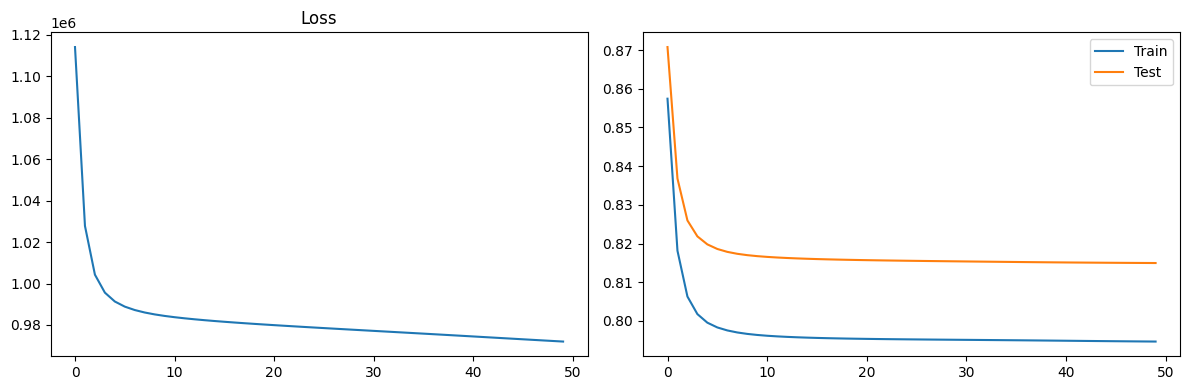

In [33]:
user_factors, item_factors , user_biases, item_biases, loss_hist, train_rmse, test_rmse = train_als(
    data_by_user_train, data_by_movie_train, data_by_user_test,
    factor_number= 2, lambda_val= 0.1, gamma=0.04, tau= 1.9, n_iters=50
)
loss_rmse(loss_hist, train_rmse, test_rmse, filename ="pdf_reports/rmse_and_loss_full_model.pdf")

### **Embedding plot  for movies embeddings**

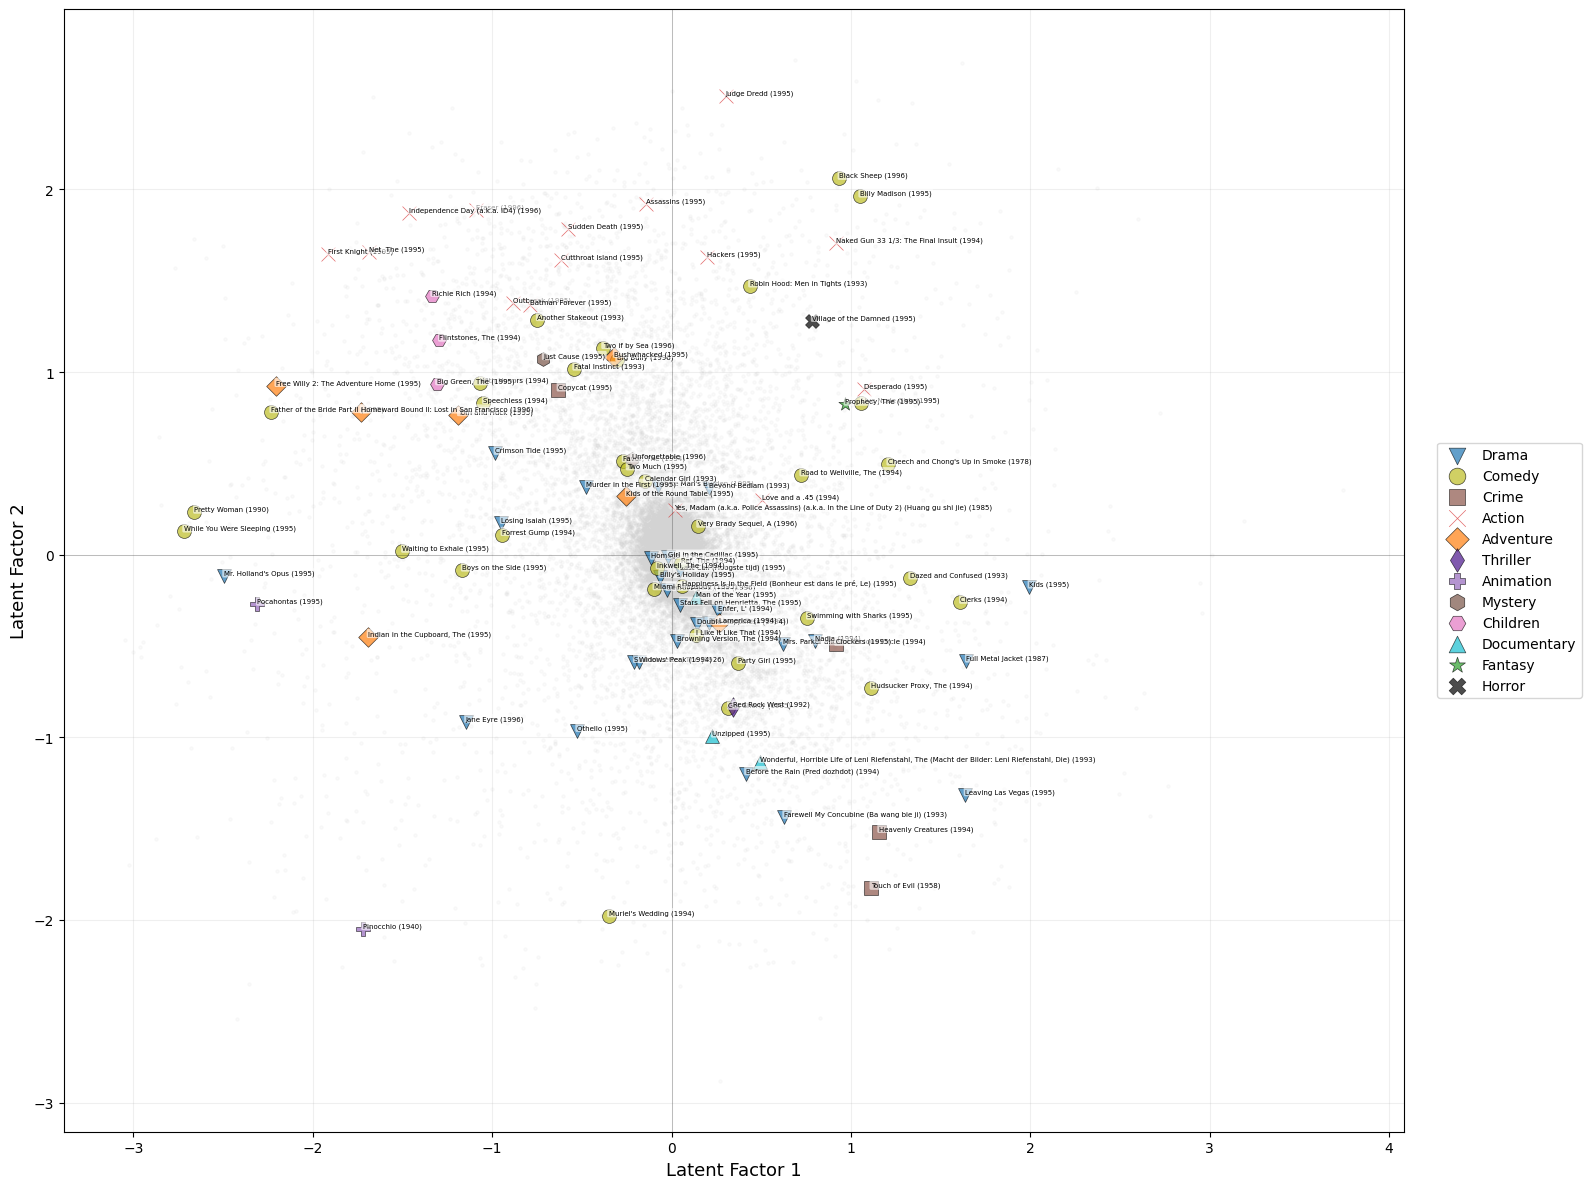

In [35]:
from visualization.plot_embedding_movie import plot_embedding_movie
plot_embedding_movie(item_factors,idx_to_movie,data_by_movie,movieid_to_title)

### **Polarisation for model without features embeddings**

In [17]:
MIN_RATINGS_POLARIZING = 1
MIN_RATINGS_NONPOLARIZING = 1
TOP_CANDIDATES = 200_000_000
TOP_K = 10

#plot_dummy_user_predictions(predictions_full_bias, predictions_scaled_bias, idx_to_movie, movieid_to_title, data_by_movie_train, dummy_movie_idx, filename_prefix="plot_dummy_user")

polarization = compute_polarization(item_factors)

polarizing_idx = select_movies_by_polarization(
    polarization,
    idx_to_movie,
    movieid_to_idx,
    data_by_movie_train,
    top_k=TOP_K,
    min_ratings=MIN_RATINGS_POLARIZING,
    most_polarizing=True
)




In [18]:

nonpolarizing_idx = select_movies_by_polarization(
    polarization,
    idx_to_movie,
    movieid_to_idx,
    data_by_movie_train,
    top_k=TOP_K,
    min_ratings=MIN_RATINGS_NONPOLARIZING,
    most_polarizing=False
)

df_stats = build_polarization_dataframe(
    polarizing_idx,
    nonpolarizing_idx,
    polarization,
    idx_to_movie,
    movieid_to_idx,
    data_by_movie_train,
    movieid_to_title
)

print(df_stats)



                                                Movie  Polarization  \
0   Lord of the Rings: The Return of the King, The...  9.374704e+00   
1   Lord of the Rings: The Fellowship of the Ring,...  9.259604e+00   
2       Lord of the Rings: The Two Towers, The (2002)  9.253417e+00   
3              Dumb & Dumber (Dumb and Dumber) (1994)  7.967179e+00   
4           Star Wars: Episode IV - A New Hope (1977)  7.510818e+00   
5                   Ace Ventura: Pet Detective (1994)  7.398796e+00   
6                         Natural Born Killers (1994)  7.276554e+00   
7   Star Wars: Episode V - The Empire Strikes Back...  7.215064e+00   
8   Star Wars: Episode VI - Return of the Jedi (1983)  7.060011e+00   
9       Harry Potter and the Half-Blood Prince (2009)  7.038116e+00   
10                       Ghosts with Shit Jobs (2012)  4.447218e-07   
11                                Övertidskrig (2012)  4.447218e-07   
12                             The Jade Raksha (1968)  1.737875e-06   
13    

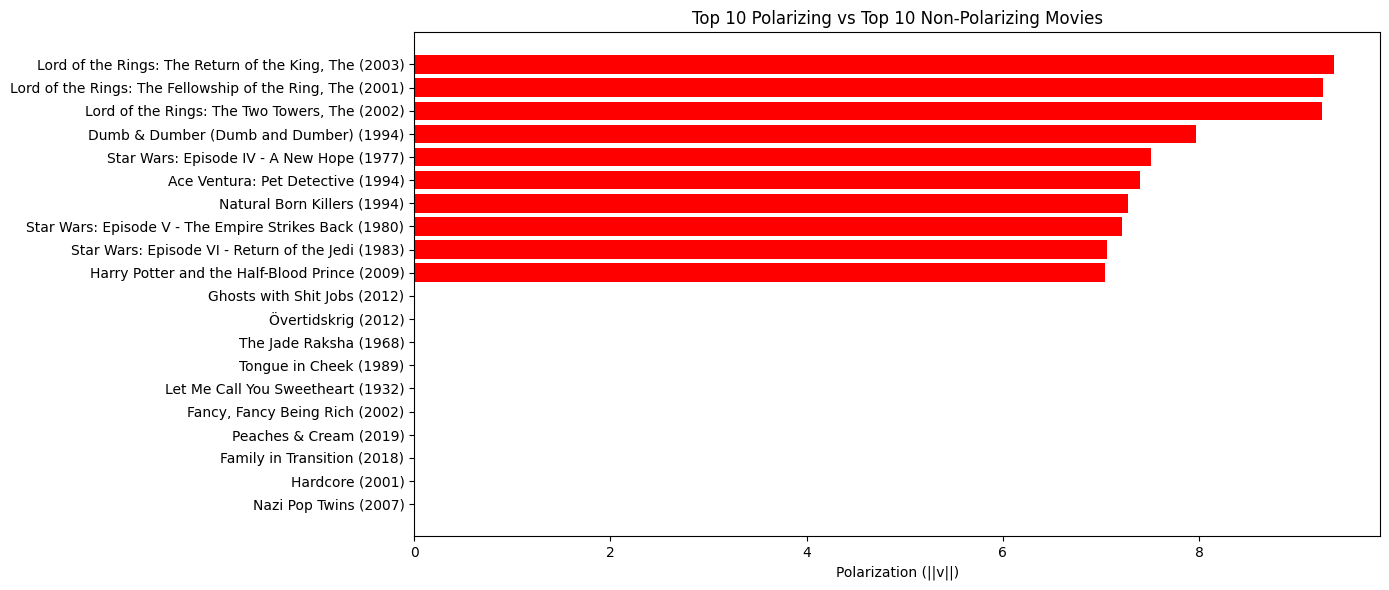

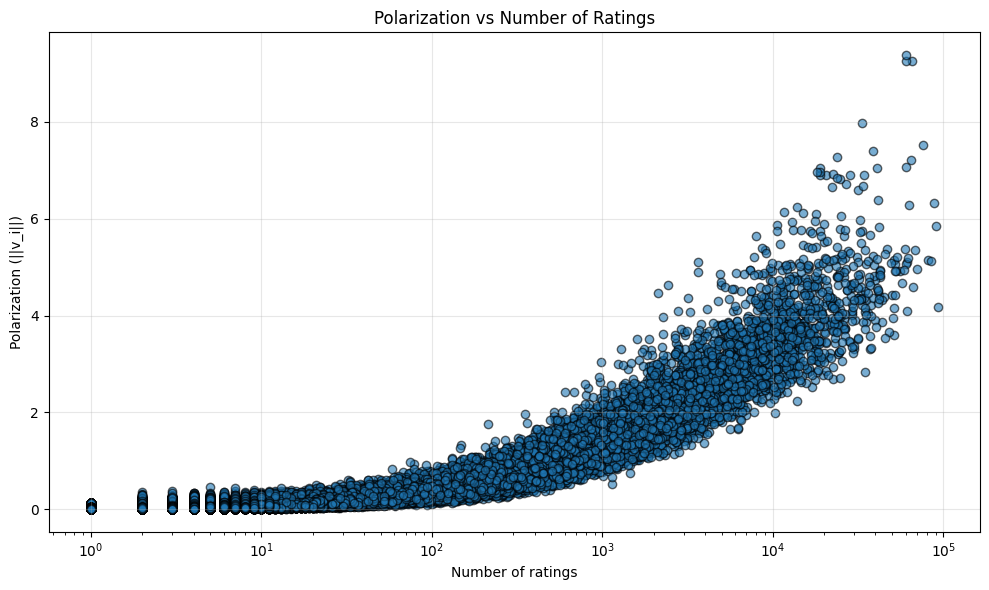

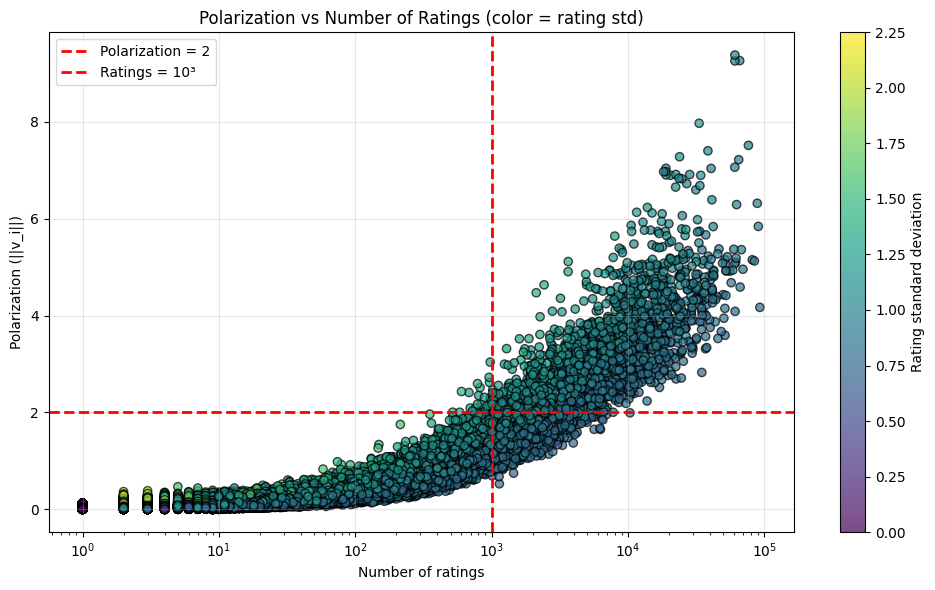

In [19]:
plot_top_polarization(df_stats)
plot_polarization_vs_count(polarization, data_by_movie_train)
plot_polarization_with_std(polarization, data_by_movie_train)

# **Practical 5**

**Adding Features**


In [7]:
from models.als_features import train_als_features
from data.features import load_features

Iter 1: Train RMSE=0.8369, Test RMSE=0.8698, Loss=1080007.4246
Iter 2: Train RMSE=0.7507, Test RMSE=0.8165, Loss=916867.5813
Iter 3: Train RMSE=0.7252, Test RMSE=0.7934, Loss=871180.8159
Iter 4: Train RMSE=0.7144, Test RMSE=0.7833, Loss=851995.9030
Iter 5: Train RMSE=0.7089, Test RMSE=0.7781, Loss=841895.4320
Iter 6: Train RMSE=0.7057, Test RMSE=0.7751, Loss=835682.0221
Iter 7: Train RMSE=0.7036, Test RMSE=0.7732, Loss=831444.6830
Iter 8: Train RMSE=0.7021, Test RMSE=0.7719, Loss=828327.4975
Iter 9: Train RMSE=0.7010, Test RMSE=0.7710, Loss=825952.6007
Iter 10: Train RMSE=0.7002, Test RMSE=0.7703, Loss=824068.2986
Iter 11: Train RMSE=0.6996, Test RMSE=0.7698, Loss=822533.4094
Iter 12: Train RMSE=0.6991, Test RMSE=0.7695, Loss=821245.8317
Iter 13: Train RMSE=0.6987, Test RMSE=0.7692, Loss=820144.6725
Iter 14: Train RMSE=0.6984, Test RMSE=0.7690, Loss=819186.5665
Iter 15: Train RMSE=0.6981, Test RMSE=0.7688, Loss=818338.8526
Iter 16: Train RMSE=0.6979, Test RMSE=0.7687, Loss=817584.9904


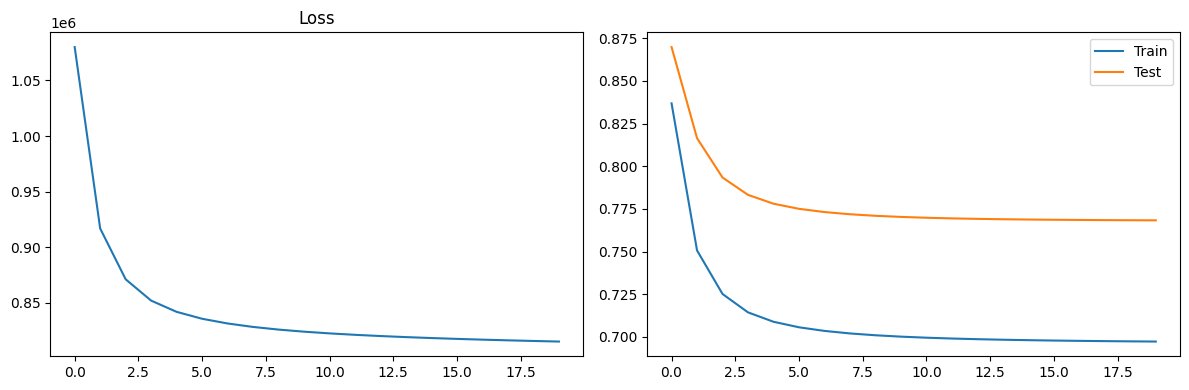

In [8]:
item_features, features_having_items = load_features(data_by_movie, movieid_to_idx)
user_factors, item_factors, feature_factor , user_biases, item_biases, loss_hist, train_rmse_history, test_rmse_history = train_als_features(
    data_by_user_train, data_by_movie_train, data_by_user_test,
    item_features,
    features_having_items,
    factor_number= 15, 
    lambda_val=0.1,   
    gamma= 0.04,       
    tau= 2.1,        
    n_iters=20, 
    verbose=True
)

loss_rmse(loss_hist, train_rmse_history, test_rmse_history, filename ="pdf_reports/rmse_and_loss_full_features_model.pdf")

Training K=15 ...
Iter 1: Train RMSE=0.8351, Test RMSE=0.8701, Loss=1075973.5408
Iter 2: Train RMSE=0.7467, Test RMSE=0.8141, Loss=907386.9847
Iter 3: Train RMSE=0.7227, Test RMSE=0.7926, Loss=864142.2448
Iter 4: Train RMSE=0.7125, Test RMSE=0.7831, Loss=845574.4173
Iter 5: Train RMSE=0.7070, Test RMSE=0.7780, Loss=835263.4344
Iter 6: Train RMSE=0.7037, Test RMSE=0.7749, Loss=828812.9799
Iter 7: Train RMSE=0.7016, Test RMSE=0.7730, Loss=824479.0270
Iter 8: Train RMSE=0.7001, Test RMSE=0.7718, Loss=821382.0403
Iter 9: Train RMSE=0.6991, Test RMSE=0.7709, Loss=819050.9482
Iter 10: Train RMSE=0.6984, Test RMSE=0.7703, Loss=817191.0744
Iter 11: Train RMSE=0.6978, Test RMSE=0.7699, Loss=815657.3707
Iter 12: Train RMSE=0.6973, Test RMSE=0.7695, Loss=814366.5460
Iter 13: Train RMSE=0.6969, Test RMSE=0.7692, Loss=813257.2679
Iter 14: Train RMSE=0.6966, Test RMSE=0.7690, Loss=812289.1258
Iter 15: Train RMSE=0.6963, Test RMSE=0.7688, Loss=811430.1874
Iter 16: Train RMSE=0.6961, Test RMSE=0.7687,

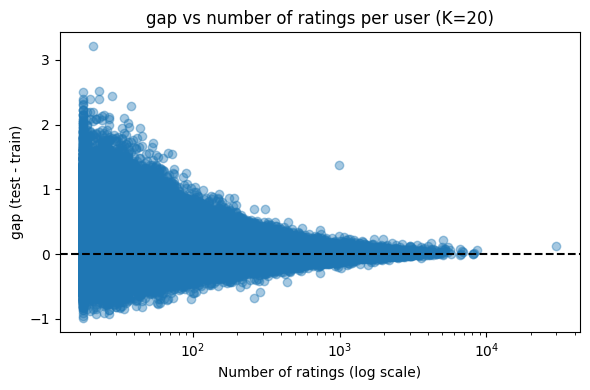

In [9]:
from tuning.overfitting_checking import evaluate_over_K
results = evaluate_over_K_with_f(train_als_features, data_by_user_train, data_by_movie_train, data_by_user_test,
    item_features,features_having_items)

plot_gap_vs_counts(results, 20)


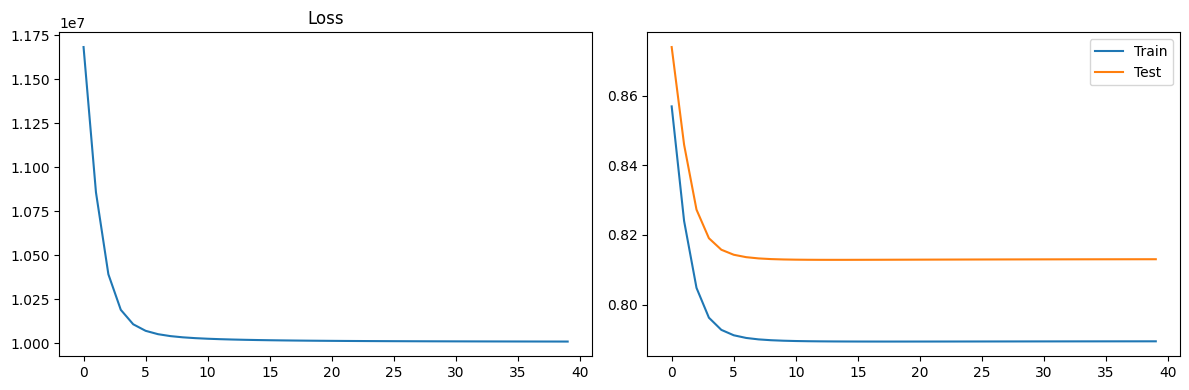

In [ ]:
item_features, features_having_items = load_features(data_by_movie, movieid_to_idx)
user_factors_2D, item_factors_2D, feature_factor_2D , user_biases_2D, item_biases_2D, loss_hist_2D, train_rmse_history_2D, test_rmse_history_2D = train_als_features(
    data_by_user_train, data_by_movie_train, data_by_user_test,
    item_features,
    features_having_items,
    factor_number= 2, 
    lambda_val=1.1,   
    gamma= 0.04,       
    tau= 5.9,        
    n_iters=40, 
    verbose=False
)

loss_rmse(loss_hist_2D, train_rmse_history_2D, test_rmse_history_2D, filename ="pdf_reports/rmse_and_loss_full_features_model.pdf")

### **Embeddings plot for features embeddings**

/var/autofs/misc/home/aimeloick/Documents/ML-SCALE/recommender_als/visualization/plot_embeddings_features.py:43: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, c=style['color'], marker=style['marker'],


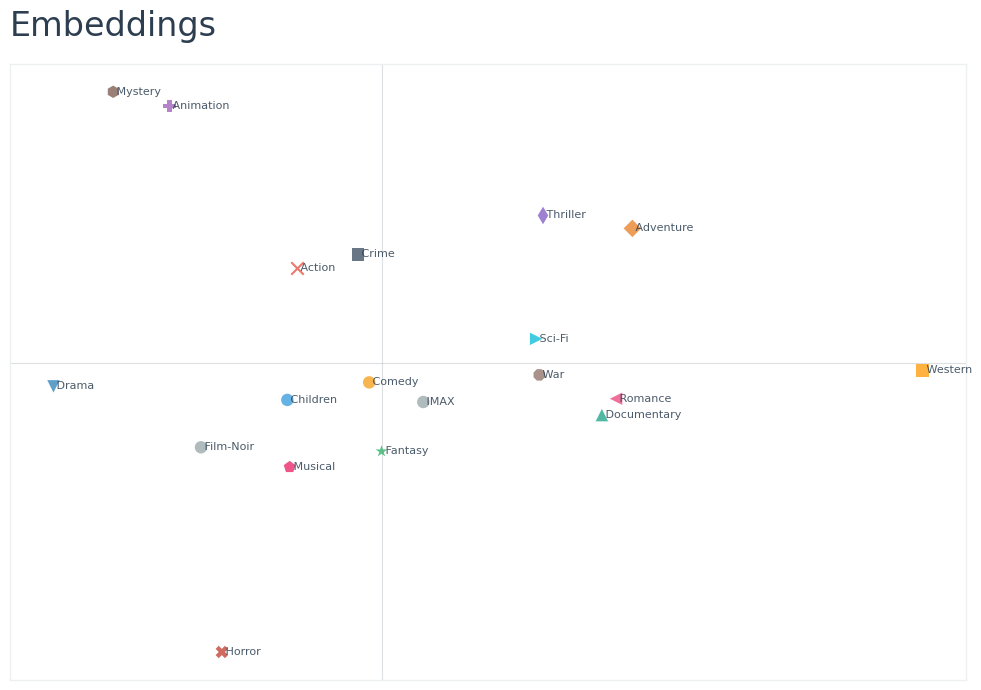


✅ Clean figure saved as PDF with 19 genre vectors


In [ ]:
from visualization.plot_embeddings_features import plot_genre_embeddings
plot_genre_embeddings(feature_factor_2D)

### **Predictions for model with features embeddings**

In [23]:
movie_title = "Lord of the Rings: The Two Towers, The (2002)"

dummy_ratings, dummy_movie_idx, _, movieid_to_title = build_dummy_rating(
    movie_title,
    movieid_to_idx,
    rating_value=5.0,
    movies_csv_path="ml-32m/movies.csv"
)

print("Dummy ratings:", dummy_ratings)

dummy_user_factors, dummy_user_bias = compute_dummy_user(item_factors, item_biases, dummy_ratings, K=15,
    lambda_val=0.1,
    tau= 2.1,
    gamma_bias=0.04
)

print("Dummy user latent factors:", dummy_user_factors)
print("Dummy user bias:", dummy_user_bias)

# ------------------------------
# Prédictions pour le dummy user
# ------------------------------
num_items = item_factors.shape[0]
predictions_full_bias = []
predictions_scaled_bias = []

for item_idx in range(num_items):
    score_full_bias = np.dot(dummy_user_factors, item_factors[item_idx]) + item_biases[item_idx]
    score_scaled_bias = np.dot(dummy_user_factors, item_factors[item_idx]) + 0.05 * item_biases[item_idx]
    predictions_full_bias.append((item_idx, score_full_bias))
    predictions_scaled_bias.append((item_idx, score_scaled_bias))

# -------- Tri --------
predictions_full_bias.sort(key=lambda x: x[1], reverse=True)
predictions_scaled_bias.sort(key=lambda x: x[1], reverse=True)

print("\n🎬 Top 10 Recommendations (bias complet)")
for item_idx, score in predictions_full_bias[:10]:
    movie_id = list(movieid_to_idx.keys())[list(movieid_to_idx.values()).index(item_idx)]
    title = movieid_to_title.get(movie_id, f"MovieIdx {item_idx}")
    print(f"- {title} | Score prédit : {score:.4f}")

print("\n🎬 Top 10 Recommendations (bias pondéré 0.05)")
for item_idx, score in predictions_scaled_bias[:10]:
    movie_id = list(movieid_to_idx.keys())[list(movieid_to_idx.values()).index(item_idx)]
    title = movieid_to_title.get(movie_id, f"MovieIdx {item_idx}")
    print(f"- {title} | Score prédit : {score:.4f}")

Dummy ratings: [(596, 5.0)]
Dummy user latent factors: [ 0.07369941  0.1277712   0.14393528 -0.19202995  0.03851297  0.0657249
 -0.10460733 -0.11899594 -0.02958949 -0.17550583 -0.01391145  0.05981294
 -0.0175294  -0.06051662  0.05596062]
Dummy user bias: 0.6357535

🎬 Top 10 Recommendations (bias complet)
- Lord of the Rings: The Return of the King, The (2003) | Score prédit : 4.1802
- Lord of the Rings: The Fellowship of the Ring, The (2001) | Score prédit : 4.1664
- Lord of the Rings: The Two Towers, The (2002) | Score prédit : 4.1099
- Wesley (2009) | Score prédit : 2.6370
- Destination: Pluto Beyond the Flyby (2016) | Score prédit : 2.5737
- Star Wars: Episode IV - A New Hope (1977) | Score prédit : 2.3209
- Pilgrim's Progress - Journey To Heaven (2008) | Score prédit : 2.2845
- Crazy Bible (2018) | Score prédit : 2.2845
- Star Wars: Episode V - The Empire Strikes Back (1980) | Score prédit : 2.2564
- WWE: The Triumph and Tragedy of World Class Championship Wrestling (2007) | Score 

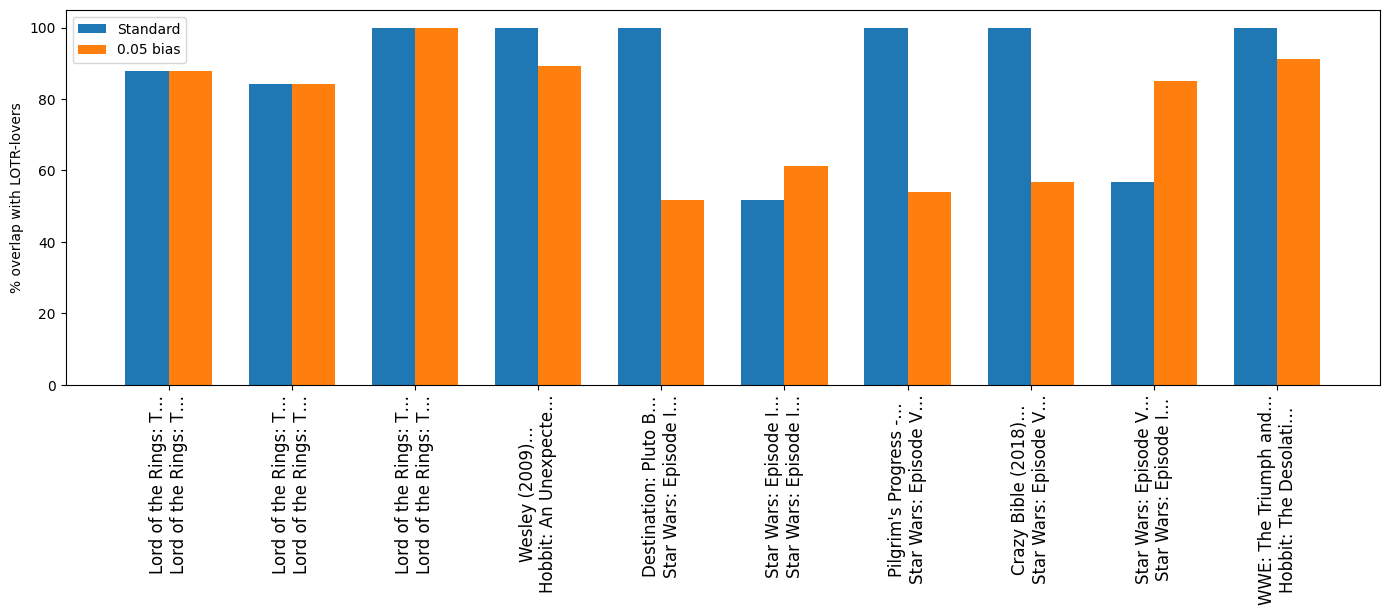

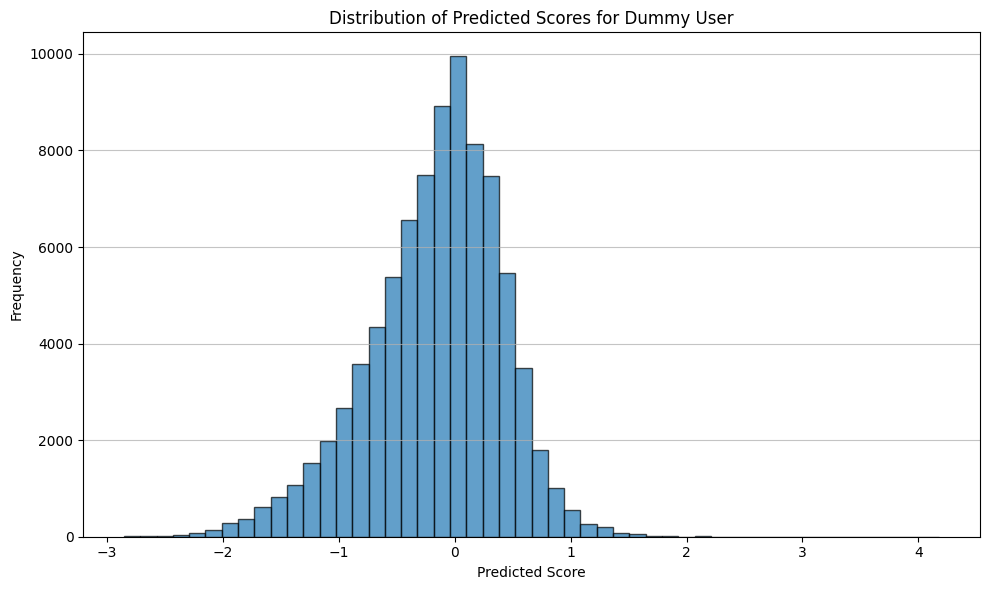

In [24]:
MIN_RATINGS_POLARIZING = 1
MIN_RATINGS_NONPOLARIZING = 1
TOP_CANDIDATES = 200_000_000
TOP_K = 10

plot_dummy_user_predictions(predictions_full_bias, predictions_scaled_bias, idx_to_movie, movieid_to_title, data_by_movie_train, dummy_movie_idx, filename_prefix="plot_dummy_user")



### **Polarisation for model with features embeddings**

In [25]:
polarization = compute_polarization(item_factors)
polarizing_idx = select_movies_by_polarization(
    polarization,
    idx_to_movie,
    movieid_to_idx,
    data_by_movie_train,
    top_k=TOP_K,
    min_ratings=MIN_RATINGS_POLARIZING,
    most_polarizing=True
)
nonpolarizing_idx = select_movies_by_polarization(
    polarization,
    idx_to_movie,
    movieid_to_idx,
    data_by_movie_train,
    top_k=TOP_K,
    min_ratings=MIN_RATINGS_NONPOLARIZING,
    most_polarizing=False
)
df_stats = build_polarization_dataframe(
    polarizing_idx,
    nonpolarizing_idx,
    polarization,
    idx_to_movie,
    movieid_to_idx,
    data_by_movie_train,
    movieid_to_title
)

print(df_stats)


                                                Movie  Polarization  \
0   Lord of the Rings: The Return of the King, The...      9.328671   
1   Lord of the Rings: The Fellowship of the Ring,...      9.270726   
2       Lord of the Rings: The Two Towers, The (2002)      9.223004   
3           Star Wars: Episode IV - A New Hope (1977)      8.061580   
4              Dumb & Dumber (Dumb and Dumber) (1994)      8.018720   
5   Star Wars: Episode V - The Empire Strikes Back...      7.856292   
6   Star Wars: Episode VI - Return of the Jedi (1983)      7.736434   
7   Star Wars: Episode II - Attack of the Clones (...      7.467382   
8    Star Wars: Episode I - The Phantom Menace (1999)      7.427936   
9                         Natural Born Killers (1994)      7.374081   
10                                  Cinderella (1960)      0.059135   
11                                   Jack & Me (1973)      0.059797   
12                       Starting a Skyscraper (1902)      0.061973   
13    

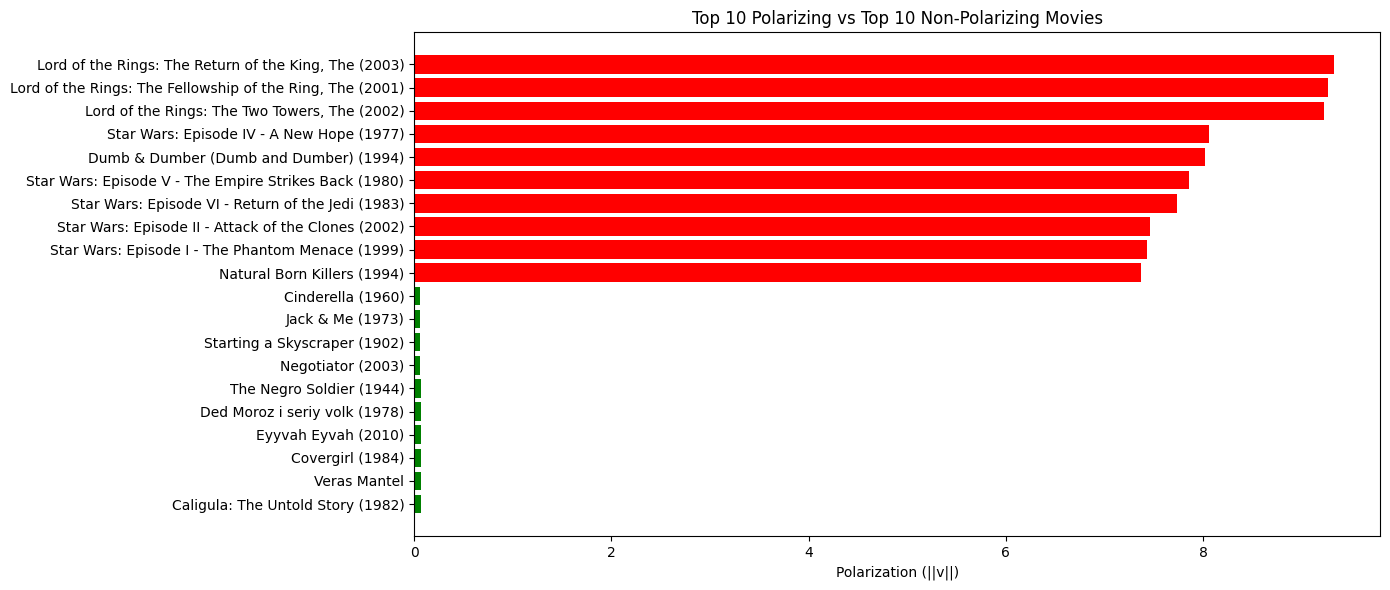

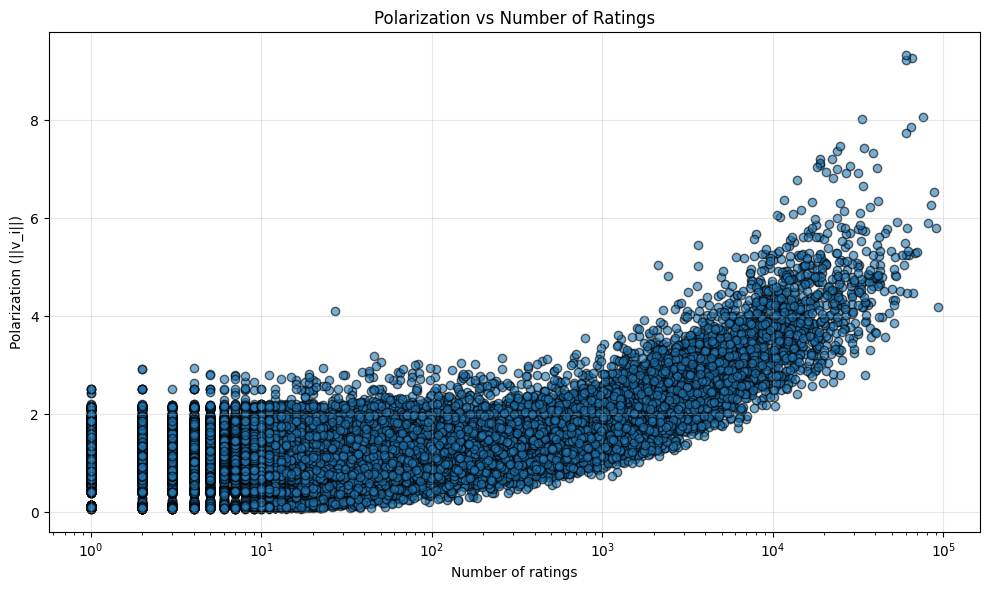

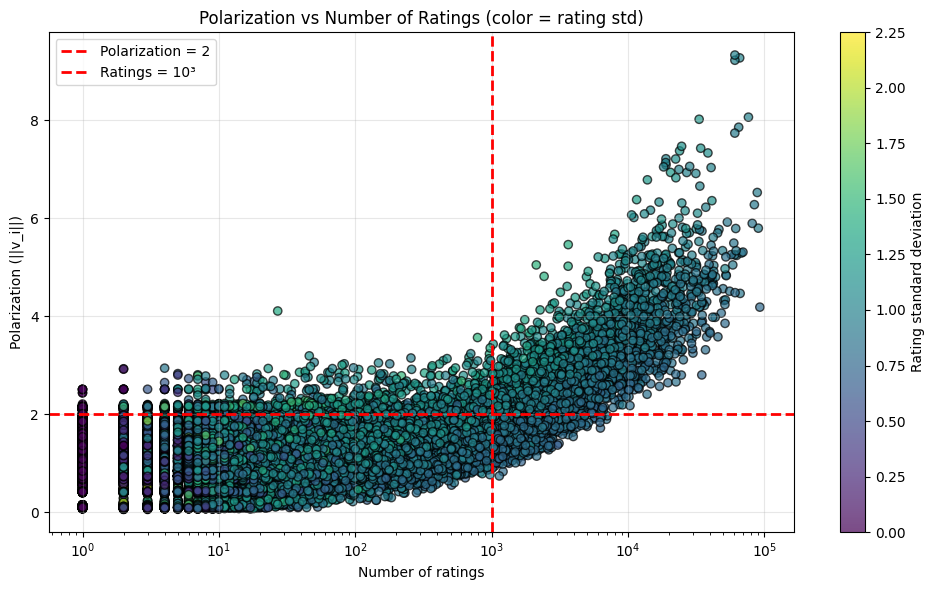

In [26]:
plot_top_polarization(df_stats)
plot_polarization_vs_count(polarization, data_by_movie_train, filename="pdf_reports/polarisation_top")
plot_polarization_with_std(polarization, data_by_movie_train, filename="pdf_reports/polarisation_degree")